<a href="https://colab.research.google.com/github/gonzalezmendez/An-lisis-Exploratorio-y-Wrangling-EDA-/blob/main/EDA_Audio_Features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Se realiza la consulta de la base de datos de kaggle, por lo que es necesario precargar con <code>kagglehub</code>,<code>so</code> y despues leer los datos con <code>pandas</code>; usaremos como visualizadores <code>seaborn</code> y <code>matplotlib</code>

In [1]:
import kagglehub
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
path = kagglehub.dataset_download("saichaitanyareddyai/spotify-tracks-dataset-audio-features")
data = os.listdir(path)

file = [f for f in data if f.endswith('.csv')][0]
full_path = os.path.join(path, file)

df = pd.read_csv(full_path)

df.sample(5)

100%|██████████| 7.90M/7.90M [00:00<00:00, 98.2MB/s]

Extracting files...


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
13973,28zsEvmvMB3oZDzsqSOhXR,Mr. Fingers,What About This Love?,What About This Love? - Extended Version,7,398349,False,0.692,0.628,3,-11.246,0,0.0325,0.0314,0.000001,0.0672,0.788,113.036,4,chicago-house
20610,7tlJOCt4FeyZQkhsTbddts,Charlie Puth,CHARLIE,Tears On My Piano,49,181124,False,0.557,0.730,1,-5.505,0,0.0939,0.2350,0.000021,0.1140,0.836,192.199,4,dance
99538,4jEdoSDTKhIwu1OcyQfcrw,Damien Rice,Coffee Moment,Cannonball,0,289693,False,0.634,0.323,1,-13.533,1,0.0318,0.8300,0.000090,0.1250,0.488,147.943,4,singer-songwriter
105325,4jQb8huQlGheFQf794ZRKW,Wasted Glitter,Rainy Nights,Rainy Nights,13,109333,False,0.737,0.208,11,-10.966,0,0.2580,0.6830,0.957000,0.1080,0.788,90.131,4,study
111701,4R9pnPnhz5KXAGbF8RLHMs,FKA twigs,LP1,Give Up,39,257560,False,0.666,0.550,9,-9.321,0,0.0497,0.0320,0.001980,0.1850,0.471,110.029,4,trip-hop


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          114000 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        114000 non-null  int64  
 5   duration_ms       114000 non-null  int64  
 6   explicit          114000 non-null  bool   
 7   danceability      114000 non-null  float64
 8   energy            114000 non-null  float64
 9   key               114000 non-null  int64  
 10  loudness          114000 non-null  float64
 11  mode              114000 non-null  int64  
 12  speechiness       114000 non-null  float64
 13  acousticness      114000 non-null  float64
 14  instrumentalness  114000 non-null  float64
 15  liveness          114000 non-null  float64
 16  valence           11

# Se observa la falta de datos en alguna fila de las columnas "artist"-"album_name"-"track_name"; por la dimencion que se trata, se considera la mejor opcion es localizar y eliminar dicho valor.

In [4]:
df.dropna(subset=['artists', 'album_name', 'track_name'], inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113999 entries, 0 to 113999
Data columns (total 20 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   track_id          113999 non-null  object 
 1   artists           113999 non-null  object 
 2   album_name        113999 non-null  object 
 3   track_name        113999 non-null  object 
 4   popularity        113999 non-null  int64  
 5   duration_ms       113999 non-null  int64  
 6   explicit          113999 non-null  bool   
 7   danceability      113999 non-null  float64
 8   energy            113999 non-null  float64
 9   key               113999 non-null  int64  
 10  loudness          113999 non-null  float64
 11  mode              113999 non-null  int64  
 12  speechiness       113999 non-null  float64
 13  acousticness      113999 non-null  float64
 14  instrumentalness  113999 non-null  float64
 15  liveness          113999 non-null  float64
 16  valence           113999 

In [5]:
df.describe()

,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,113999.000000,1.139990e+05,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000,113999.000000
mean,33.238827,2.280312e+05,0.566801,0.641383,5.309126,-8.258950,0.637558,0.084652,0.314907,0.156051,0.213554,0.474066,122.147695,3.904034
std,22.304959,1.072961e+05,0.173543,0.251530,3.559999,5.029357,0.480708,0.105733,0.332522,0.309556,0.190378,0.259261,29.978290,0.432623
min,0.000000,8.586000e+03,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218500,4.000000
50%,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.597500,0.049000,0.273000,0.683000,140.071000,4.000000
max,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


# 1. Popularidad:
- Contamos con una media de 33.2 y una desviacion estandard de 22.3.

**Insight** Se observa en el dataset una gran cantidad de canciones con popularidad 0 (el mínimo). Esto sugiere que hay muchas pistas "nicho" o poco conocidas, mientras que el 75% de los datos están por debajo de 50 puntos. Las canciones con popularidad cercana a 100 son valores atípicos (outliers) muy escasos.

# 2. Caracteristicas de Audio
- **Energia vs Acustica:** La media de energy es alta (0.64), mientras que la de acousticness es baja (0.31). Esto indica que el dataset tiende a música más producida/eléctrica que acústica.
- **Instrumentabilida:** El 50% de las canciones (mediana) tiene un valor de casi cero (0.000042).

**Insight** La gran mayoría de las pistas en este dataset contienen voces; las pistas puramente instrumentales son la minoría.

# 3. Dinámica y Tempo

- **Loudness (Sonoridad):** El rango va desde -49.5 dB hasta 4.5 dB, con una media de -8.25 dB.
  - **Insight:** La mayoría de la música está comprimida para sonar fuerte (cerca de los -5 a -10 dB), que es el estándar de la industria moderna.
- **Tempo:** El promedio es de 122 BPM, que es el "corazón" del pop y el house. Lo curioso es el mínimo de 0 BPM, lo cual podría indicar ruidos, podcasts o errores de medición que deberías investigar.


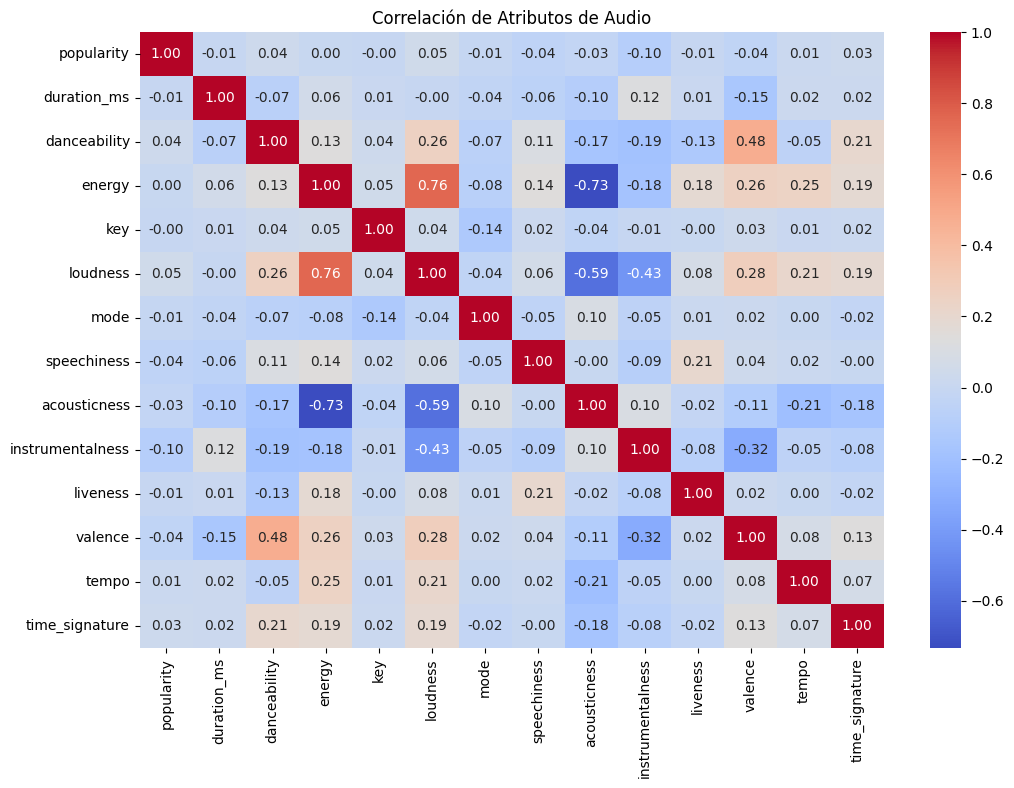

In [6]:
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlación de Atributos de Audio')
plt.show()

In [7]:
top_genres = df['track_genre'].value_counts().nlargest(10).index
df_top = df[df['track_genre'].isin(top_genres)]
df_top.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [8]:
df_top.tail()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
9995,1GM1o7Wgh3UhqgMf5Yqou6,Armandinho,Acústico (Ao Vivo),O Que Meu Pai Falou Pra Mim - Ao Vivo,42,252390,False,0.629,0.581,7,-9.571,1,0.0420,0.5470,0.000018,0.6810,0.299,86.005,4,brazil
9996,3UFZkGoRoqZD2gp0ayZlM7,Canção & Louvor,Profetizando Vida,Dependente,43,270791,False,0.647,0.459,2,-6.737,0,0.0331,0.5860,0.000000,0.1900,0.201,135.824,4,brazil
9997,0VYLCqCYrLo2aZ1mcdVDjH,Planet Hemp,Usuário,"Não Compre, Plante!",42,251493,False,0.652,0.780,0,-8.433,1,0.0507,0.0195,0.033400,0.1860,0.656,112.680,4,brazil
9998,5BtFkPust4wifo9KOThNGI,Cidade Negra;Lulu Santos,Quanto Mais Curtido Melhor,Sábado a Noite (feat. Lulu Santos),42,267306,False,0.773,0.940,1,-5.303,0,0.0792,0.1930,0.000000,0.1900,0.887,97.135,4,brazil
9999,3TAxLyCtWcLqPBVE1rtj6k,Legião Urbana,O Descobrimento Do Brasil,Vamos Fazer Um Filme,44,261866,False,0.674,0.437,0,-14.639,1,0.0297,0.4140,0.099600,0.0713,0.844,117.738,4,brazil


In [9]:
df_top.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          10000 non-null  object 
 1   artists           10000 non-null  object 
 2   album_name        10000 non-null  object 
 3   track_name        10000 non-null  object 
 4   popularity        10000 non-null  int64  
 5   duration_ms       10000 non-null  int64  
 6   explicit          10000 non-null  bool   
 7   danceability      10000 non-null  float64
 8   energy            10000 non-null  float64
 9   key               10000 non-null  int64  
 10  loudness          10000 non-null  float64
 11  mode              10000 non-null  int64  
 12  speechiness       10000 non-null  float64
 13  acousticness      10000 non-null  float64
 14  instrumentalness  10000 non-null  float64
 15  liveness          10000 non-null  float64
 16  valence           10000 non-null  float64
 17 

/tmp/ipykernel_335/1078311996.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='track_genre', y='popularity', data=df_top, palette='viridis')


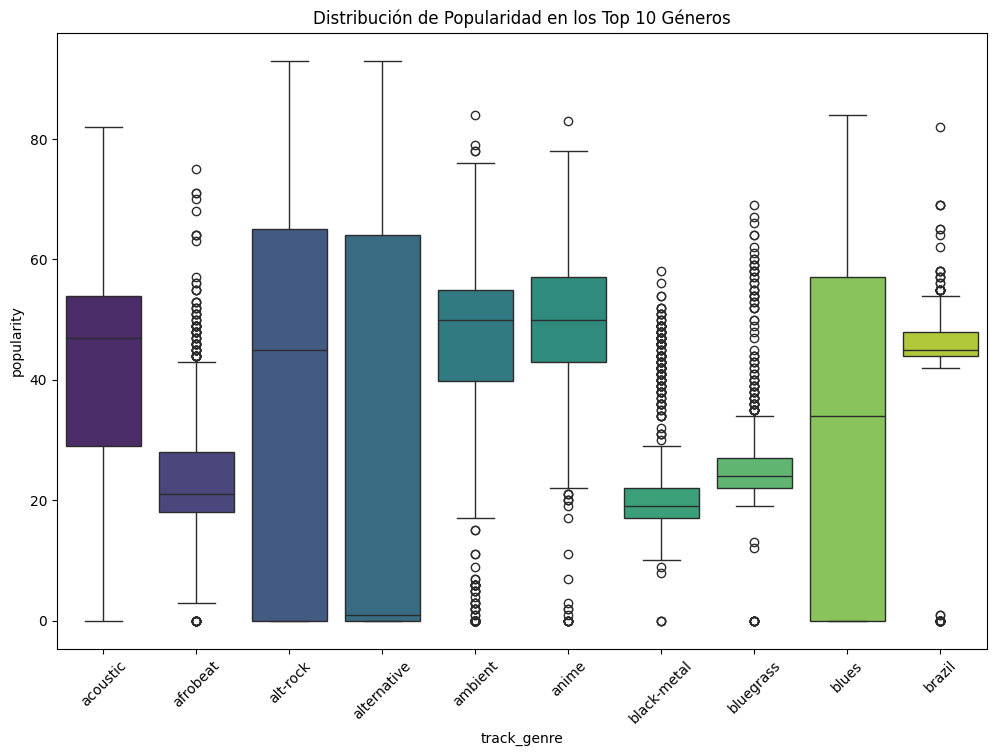

In [10]:
plt.figure(figsize=(12, 8))
sns.boxplot(x='track_genre', y='popularity', data=df_top, palette='viridis')
plt.xticks(rotation=45)
plt.title('Distribución de Popularidad en los Top 10 Géneros')
plt.show()

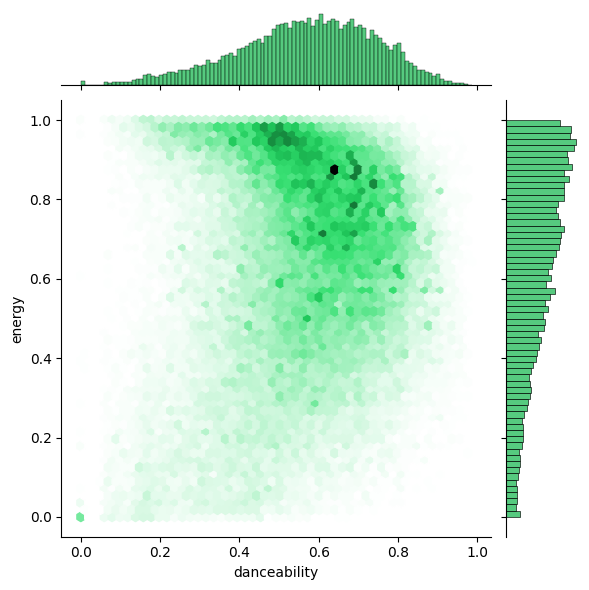

In [11]:
sns.jointplot(x='danceability', y='energy', data=df, kind='hex', color='#1DB954')

plt.show()